# RTM (Reverse Time Migration) - Обратная временная миграция

В этом ноутбуке мы реализуем **RTM (Reverse Time Migration)** - один из самых точных методов миграции сейсмических данных.

## План работы:
1. **Создание модели** - создадим чуть более сложную скоростную модель чем в предыдущих примерах и съемку с 3-мя источниками
2. **Имитация полевого наблюдения** - прямое моделирование волны от источника с точной скоростной моделью и получение сейсмограмм
3. **RTM: forward-поле** - создание сглаженной модели для RTM и получение поля волны от источников
4. **RTM: backward-поле** - получение поля в обратном времени от приемников с той же гладкой моделью
5. **Условие изображения** - кросс-корреляция волновых полей для каждого источника/сейсмограммы и суммирование их в общее изображение


## Теоретические основы RTM

**RTM (Reverse Time Migration)** основан на решении волнового уравнения в обратном времени:

1. **Прямое моделирование**: Решаем волновое уравнение от источника во времени
2. **Обратное моделирование**: Решаем волновое уравнение от приемников в обратном времени  
3. **Условие изображения**: Кросс-корреляция прямого и обратного волновых полей

**Преимущества RTM:**
- Точная обработка многократных отражений
- Корректная обработка сложной геометрии
- Высокое разрешение изображения
- Гибкие возможности применения imaging condition за счет наличия кадров прямого и обратного полей

**Недостатки:**
- Высокие вычислительные затраты
- Требует точную модель скорости
- В самом простом варианте множество артефактов на изображении


In [1]:
# Импорты и настройки
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage  import gaussian_filter
import bruges
from tqdm.notebook import tqdm

# Настройка для лучшего отображения
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10


## 1. Создание модели

Создадим модель скорости и отражательной способности для RTM. Используем более сложную модель с волнистой границей выше основной границы. В съемки будет уже 3 источника, чтобы получить более качественное изображение


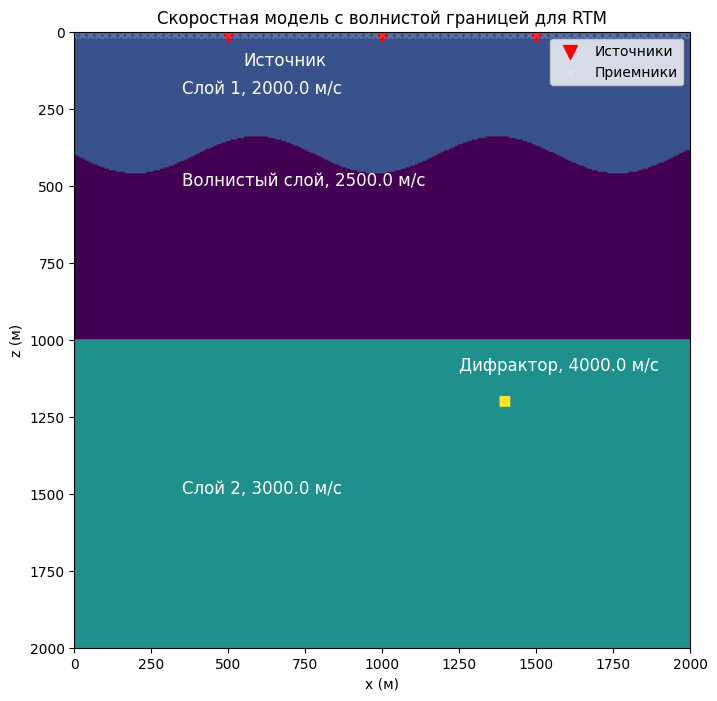

In [16]:
nx = 401
nz = 401
dx = 5
dz = 5
x = np.arange(nx) * dx
z = np.arange(nz) * dz

# Скорости слоев
v_top = 2000.0
v_middle = 2500.0  # Новый промежуточный слой
v_bottom = 3000.0

# Основная граница (глубже)
z_boundary = 1000.0
iboundary = int(z_boundary / dz)

# Параметры волнистой границы
z_wave_boundary = 400.0  # Глубина волнистой границы
wave_amplitude = 60.0    # Амплитуда волны в метрах
wave_frequency = 0.008    # Частота волны (циклов на метр)

# Создаем волнистую границу
wave_boundary_z = z_wave_boundary + wave_amplitude * np.sin(wave_frequency * x)
wave_boundary_idx = np.round(wave_boundary_z / dz).astype(int)

# Инициализируем модель скоростей
v_model = np.ones((nz, nx)) * v_bottom

# Заполняем верхний слой до основной границы
v_model[:iboundary, :] = v_top

# Добавляем волнистую границу
for i in range(nx):
    # Определяем границы волнистого слоя для данного x
    wave_top = max(0, wave_boundary_idx[i])  
    
    # Заполняем волнистый слой промежуточной скоростью
    v_model[:wave_top, i] = v_middle

# добавим дифрактор
diffractor_x = int(nx * 0.7)
diffractor_z = int(nz * 0.6)
diffractor_v = 4000.0
difw = 3 # ширина дифрактора
v_model[diffractor_z - difw:diffractor_z+difw+1, diffractor_x-difw:diffractor_x+difw+1] = diffractor_v

v_max = v_model.max()

# Параметры источника
sx  = np.array([500, 1000, 1500])
sx_idx = sx // dx
sz = np.array([10, 10, 10])
sz_idx = sz // dz

# Параметры приемников - через каждые 5 точек сетки (25 м)
rx = np.arange(0, 2025, 25)
rx_idx = rx // dx
rz = np.ones_like(rx) * 10
rz_idx = rz // dz

plt.figure(figsize=(8, 8))
plt.imshow(v_model, extent=[x.min(), x.max(), z.max(), z.min()], cmap='viridis')
plt.scatter(sx, sz, color='red', s=100, marker='v', label='Источники')
plt.scatter(rx, rz, color='white', s=20, alpha=0.2, marker='x', label='Приемники')

# Используем первый источник для подписей
plt.text(sx[0]+50, sz[0]+100, 'Источник', color='white', fontsize=12)
plt.text(sx[0]-150, 200, f'Слой 1, {v_top} м/с', color='white', fontsize=12)
plt.text(sx[0]-150, 500, f'Волнистый слой, {v_middle} м/с', color='white', fontsize=12)
plt.text(x[diffractor_x]-150, z[diffractor_z]-100, f'Дифрактор, {diffractor_v} м/с', color='white', fontsize=12)
plt.text(sx[0]-150, 1500, f'Слой 2, {v_bottom} м/с', color='white', fontsize=12)
plt.title("Скоростная модель с волнистой границей для RTM")
plt.xlabel("x (м)")
plt.ylabel("z (м)")
plt.legend()
plt.show()

In [17]:
# ----------------------------
# 1. Паддинг модели
# ----------------------------
n_pad = 120  # задаём размер паддинга
nx_padded = nx + 2 * n_pad
nz_padded = nz + 2 * n_pad  # паддинг сверху, снизу и по бокам

# Расширяем модель
v_padded = np.pad(v_model, ((n_pad, n_pad), (n_pad, n_pad)), mode='edge')

# Обновляем индексы источника и приёмников в расширенной сетке
sx_idx_padded = sx_idx + n_pad
sz_idx_padded = sz_idx + n_pad

rx_idx_padded = rx_idx + n_pad
rz_idx_padded = rz_idx + n_pad

# ----------------------------
# 2. Damping profile (поглощающий слой)
# ----------------------------
def create_damping_profile(nx_padded, nz_padded, n_pad, damping_strength=0.5):
    """
    Создаёт профиль затухания для поглощающих граничных условий.
    Затухание применяется во всей паддинг-зоне с квадратичным профилем.
    
    Параметры:
    - nx_padded, nz_padded: размеры сетки С ПАДДИНГОМ
    - n_pad: размер паддинг-зоны
    - damping_strength: максимальная сила затухания
    """
    damp = np.zeros((nz_padded, nx_padded))
    
    # Создаём маску для всей паддинг-зоны
    for i in range(n_pad):
        # Вертикальные границы (левая и правая)
        alpha_vertical = ((n_pad - i) / n_pad)**2
        damp[:, i] = np.maximum(damp[:, i], damping_strength * alpha_vertical)
        damp[:, -1 - i] = np.maximum(damp[:, -1 - i], damping_strength * alpha_vertical)
        
        # Горизонтальные границы (верхняя и нижняя)
        alpha_horizontal = ((n_pad - i) / n_pad)**2
        damp[i, :] = np.maximum(damp[i, :], damping_strength * alpha_horizontal)  
        damp[-1 - i, :] = np.maximum(damp[-1 - i, :], damping_strength * alpha_horizontal)
    
    return damp

# Увеличиваем силу поглощения для лучшего подавления отражений
damp = create_damping_profile(nx_padded, nz_padded, n_pad)

### Параметры моделирования

Настроим параметры для волнового моделирования и создадим источник.


dt_fd = 0.71 мс
CFL число = 0.800
Длина источника Рикера: 141 отсчетов
Время начала инжекции: 0.000 с
Максимальная амплитуда источника: 0.049000
Ненулевых отсчетов в source_wavelet: 141


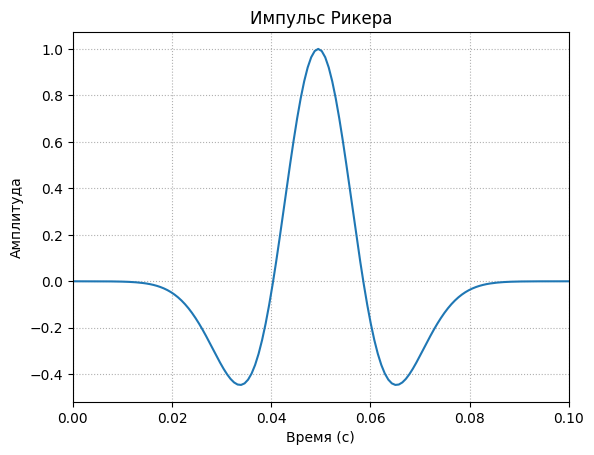

In [18]:
# ----------------------------
# 3. Временные параметры и источник
# ----------------------------
t_total = 1.5
# Условие CFL для 2D: dt ≤ min(dx, dz) / (v_max * √2)
# Для 4-го порядка точности можно использовать более консервативный коэффициент
dt_cfl = min(dx, dz) / (v_max * np.sqrt(2.0))
# Более оптимальный коэффициент для 4-го порядка (0.8 вместо 0.7)
dt_fd = 0.8 * dt_cfl
nt_fd = int(np.ceil(t_total / dt_fd))
dt_fd = t_total / nt_fd  # точное значение

# Генерация источника (Рикер)
f0 = 25.0  # Центральная частота импульса Рикера
w, t_ricker = bruges.filters.ricker(0.1, dt=dt_fd, f=f0)

source_wavelet = np.zeros(nt_fd)

source_wavelet[:len(w)] = w

print(f"dt_fd = {dt_fd*1000:.2f} мс")
print(f"CFL число = {dt_fd * v_max * np.sqrt(2.0) / min(dx, dz):.3f}")

# Диагностика источника
print(f"Длина источника Рикера: {len(t_ricker)} отсчетов")
print(f"Время начала инжекции: {0 * dt_fd:.3f} с")
print(f"Максимальная амплитуда источника: {np.max(np.abs(t_ricker)):.6f}")
print(f"Ненулевых отсчетов в source_wavelet: {np.count_nonzero(source_wavelet)}")
plt.plot(np.arange(nt_fd)*dt_fd, source_wavelet)
plt.title('Импульс Рикера')
plt.xlim(0, 0.1)
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True, linestyle=':')
plt.show()

### Лапласиан для моделирования

In [5]:
def laplacian_4th(p, inv_dx2, inv_dz2):
    """
    Лапласиан 4-го порядка точности для 2D волнового уравнения.
    Правильная формула: ∂²p/∂x² + ∂²p/∂z²
    
    Параметры:
    - p: волновое поле (2D массив)
    - inv_dx2: 1/(dx²) - обратный квадрат шага по x
    - inv_dz2: 1/(dz²) - обратный квадрат шага по z
    
    Возвращает:
    - lap: лапласиан волнового поля
    """
    lap = np.zeros_like(p)
    # Только внутренняя область (избегаем границ)
    # ∂²p/∂x²: дифференцирование по x (второй индекс)
    lap[2:-2, 2:-2] = (
        (-p[2:-2, :-4] + 16*p[2:-2, 1:-3] - 30*p[2:-2, 2:-2] + 16*p[2:-2, 3:-1] - p[2:-2, 4:]) * inv_dx2 +
        # ∂²p/∂z²: дифференцирование по z (первый индекс)  
        (-p[:-4, 2:-2] + 16*p[1:-3, 2:-2] - 30*p[2:-2, 2:-2] + 16*p[3:-1, 2:-2] - p[4:, 2:-2]) * inv_dz2
    ) / 12.0
    return lap


### Универсальная функция для прямого моделирования. Может возвращать сейсмограмму или набор снапшотов поля

In [6]:
def forward_modeling(v_padded, source_wavelet, sx_idx_padded, sz_idx_padded, 
                    rx_idx_padded, rz_idx_padded, damp, dt_fd, dx, dz, 
                    nt_fd, save_snapshots=False, snapshot_interval=50):
    """
    Прямое моделирование волнового поля.
    """    
    
    # Инициализация полей
    p_curr = np.zeros_like(v_padded)
    p_prev = np.zeros_like(p_curr)
    p_next = np.zeros_like(p_curr)
    
    inv_dx2 = 1.0 / (dx * dx)
    inv_dz2 = 1.0 / (dz * dz)
    
    # Сейсмограмма
    n_receivers = len(rx_idx_padded)
    seismogram = np.zeros((nt_fd, n_receivers))
    
    # Снапшоты
    snapshots = []
    snapshot_times = []
    snapshot_indices = []
    
    # Предварительные вычисления для стабильности
    dt2 = dt_fd ** 2
    v2 = v_padded ** 2  # Квадрат скорости
    
    print(f"Прямое моделирование: {nt_fd} шагов, {n_receivers} приемников")
    print(f"Размер модели: {v_padded.shape}")
    
    for it in tqdm(range(nt_fd), desc="Forward modeling"):
        # Вычисляем лапласиан для текущего поля
        lap = laplacian_4th(p_curr, inv_dx2, inv_dz2)
        
        # Обновление только внутренней области (исключая границы для 4-го порядка)
        i1, i2, j1, j2 = 2, -2, 2, -2
        
        # FD-схема для волнового уравнения с поглощающим слоем
        p_next[i1:i2, j1:j2] = (
            2 * p_curr[i1:i2, j1:j2] - p_prev[i1:i2, j1:j2] +
            dt2 * v2[i1:i2, j1:j2] * lap[i1:i2, j1:j2] -
            damp[i1:i2, j1:j2] * (p_curr[i1:i2, j1:j2] - p_prev[i1:i2, j1:j2])
        )
        
        # Инжекция источника 
        if it < len(source_wavelet) and source_wavelet[it] != 0:            
            p_next[sz_idx_padded, sx_idx_padded] += dt2 * source_wavelet[it]        
        
        # Обновление полей 
        p_prev, p_curr, p_next = p_curr, p_next, p_prev     
        
        # Запись сейсмограммы
        for ir in range(n_receivers):
            seismogram[it, ir] = p_curr[rz_idx_padded[ir], rx_idx_padded[ir]]
        
        # Сохранение снапшотов
        if save_snapshots and (it % snapshot_interval == 0 or it == nt_fd - 1):
            snapshots.append(p_curr.copy())
            snapshot_times.append(it * dt_fd)
            snapshot_indices.append(it)
    
    print(f"Прямое моделирование завершено. Сейсмограмма: {seismogram.shape}")
    if save_snapshots:
        print(f"Сохранено снапшотов: {len(snapshots)}")
    
    if save_snapshots:
        return seismogram, np.array(snapshots), np.array(snapshot_times), np.array(snapshot_indices)
    else:
        return seismogram

## 2.Имитация полевого наблюдения: прямое моделирование с точной моделью для получения сейсмограммы ОПВ

Начинаем прямое моделирование...
Источник 1/3 (X = 500 м)
Прямое моделирование: 2122 шагов, 81 приемников
Размер модели: (641, 641)


Forward modeling:   0%|          | 0/2122 [00:00<?, ?it/s]

Прямое моделирование завершено. Сейсмограмма: (2122, 81)
Источник 2/3 (X = 1000 м)
Прямое моделирование: 2122 шагов, 81 приемников
Размер модели: (641, 641)


Forward modeling:   0%|          | 0/2122 [00:00<?, ?it/s]

Прямое моделирование завершено. Сейсмограмма: (2122, 81)
Источник 3/3 (X = 1500 м)
Прямое моделирование: 2122 шагов, 81 приемников
Размер модели: (641, 641)


Forward modeling:   0%|          | 0/2122 [00:00<?, ?it/s]

Прямое моделирование завершено. Сейсмограмма: (2122, 81)


Text(0, 0.5, 'Время (с)')

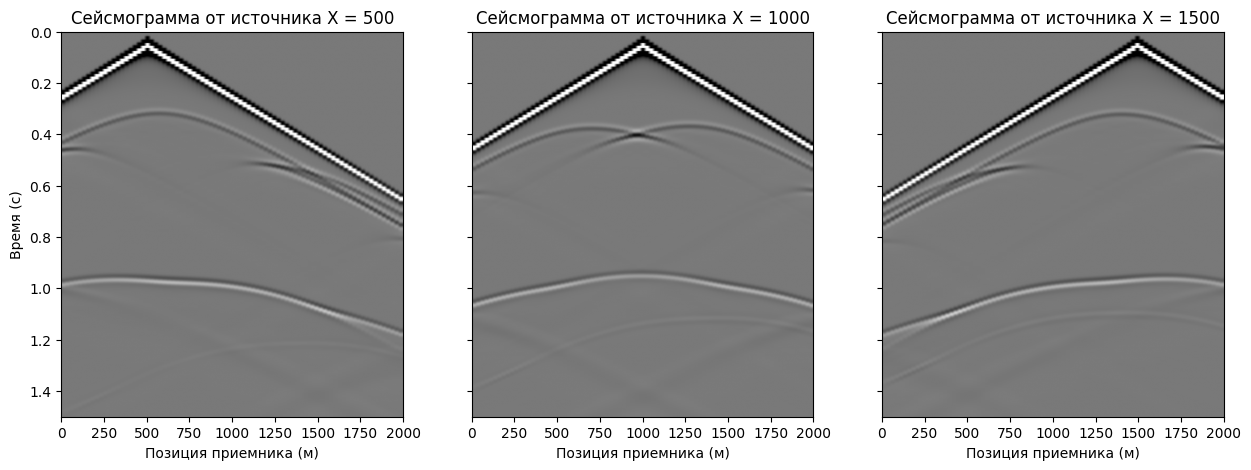

In [7]:
print("Начинаем прямое моделирование...")
seismograms = []
for source_idx, (source_x_ind, source_z_ind) in enumerate(zip(sx_idx_padded, sz_idx_padded)):    
    print(f"Источник {source_idx + 1}/3 (X = {sx[source_idx]} м)")
    seismograms.append(forward_modeling(
        v_padded, source_wavelet, source_x_ind, source_z_ind,
        rx_idx_padded, rz_idx_padded, damp, dt_fd, dx, dz, nt_fd,
        save_snapshots=False
    ))
    

vmin, vmax = np.percentile(seismograms, [1, 99])
fig, axes = plt.subplots(1, len(seismograms), figsize=(15, 5), sharey=True)
for i, seismogram in enumerate(seismograms):

    axes[i].imshow(seismogram, aspect='auto', cmap='gray', 
            extent=[rx[0], rx[-1], t_total, 0], vmin=vmin, vmax=vmax)
    axes[i].set_xlabel('Позиция приемника (м)')
    axes[i].set_title(f'Сейсмограмма от источника X = {sx[i]}')
axes[0].set_ylabel('Время (с)')

### Удаление прямой волны из сейсмограммы
Чтобы минимизировать артефакты на изображении, нужно удалить прямую волну: RTM предполагает, что на поверхности записаны только отраженные волны. Просто сделаем мьютинг, рассчитав времена прихода прямой волны, зная ее скорость

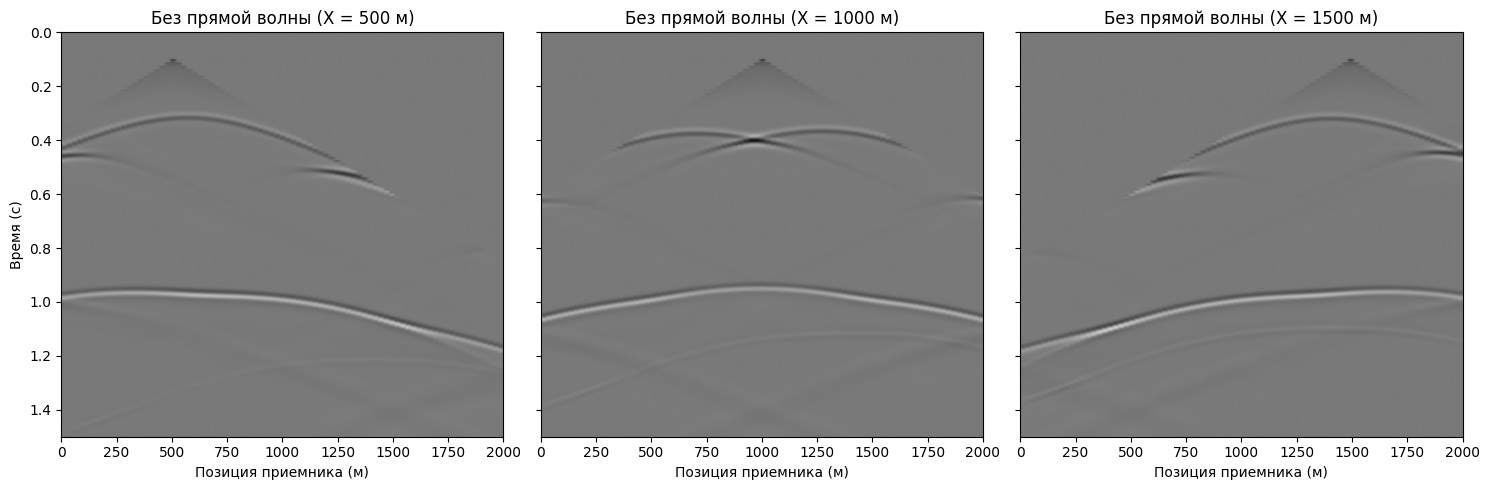

In [8]:
seismograms_clean = []
vel_direct_wave = 2000 # скорость прямой волны
window_width = 0.1 # ширина окна для удаления прямой волны

# Для каждого источника
for source_idx, (seismogram, source_x) in enumerate(zip(seismograms, sx)):
    seismogram_clean = seismogram.copy()
    
    # Для каждого приемника
    for i, rec_x in enumerate(rx):
        # Расстояние от источника до приемника
        offset = abs(rec_x - source_x)
        
        # Время прихода прямой волны
        t_direct = offset / vel_direct_wave + window_width
        
        # Индекс времени прихода прямой волны
        it_direct = int(t_direct / dt_fd)        
               
        # Удаляем прямую волну в окне
        seismogram_clean[:it_direct, i] = 0
    
    seismograms_clean.append(seismogram_clean)

# Визуализация всех трех сейсмограмм без прямой волны
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for i, (seismogram_clean, source_x) in enumerate(zip(seismograms_clean, sx)):
    axes[i].imshow(seismogram_clean, aspect='auto', cmap='gray', 
                   extent=[rx[0], rx[-1], t_total, 0], vmin=vmin, vmax=vmax)
    axes[i].set_xlabel('Позиция приемника (м)')
    axes[i].set_title(f'Без прямой волны (X = {source_x} м)')
    if i == 0:
        axes[i].set_ylabel('Время (с)')
plt.tight_layout()
plt.show()

## 3. RTM: Получение forward-поля

### Создадим гладкую модель для RTM и получим forward-поле (от источника)
Чтобы соблюсти приближение Борна (гладкая модель для кинематики волн) и исключить отражения forward-волны от границы и дифрактора, 
сгладим скорости. Кроме того, гладкая скорость имитирует полученную оценочную модель из скоростей ОГТ при обычной обработке

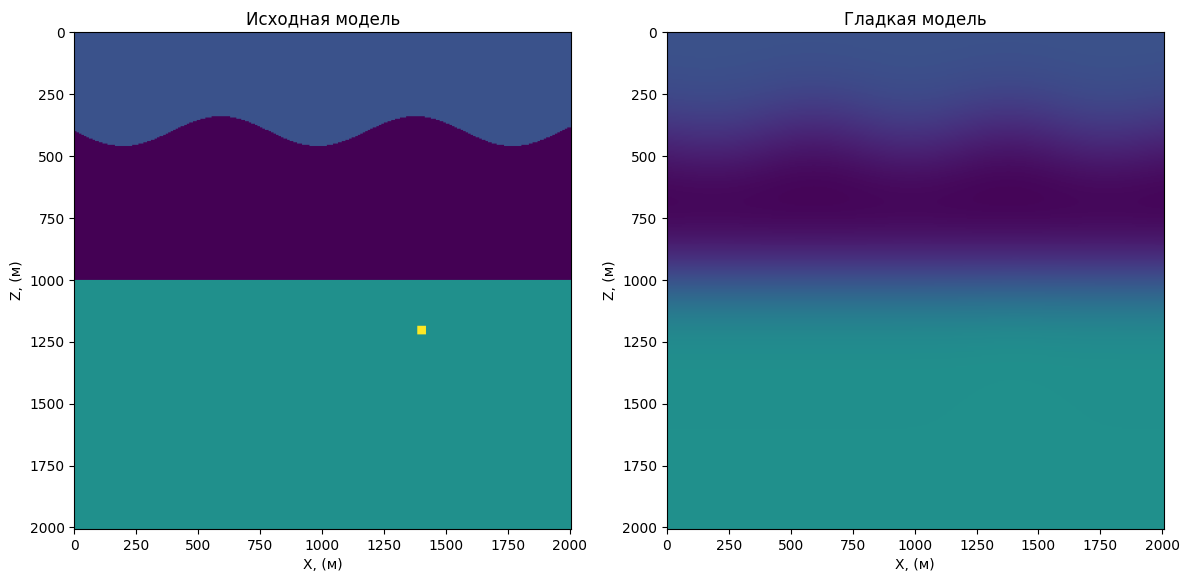

In [9]:
smooth_model = gaussian_filter(v_padded, sigma=30)

# Визуализация гладкой модели в сравнении с исходной
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

vmin, vmax = np.min(v_model), np.max(v_model)

axes[0].imshow(v_model, cmap='viridis', extent=[0, nx*dx, nz*dz, 0], vmin=vmin, vmax=vmax)
axes[0].set_title('Исходная модель')
axes[0].set_xlabel('X, (м)')
axes[0].set_ylabel('Z, (м)')

axes[1].imshow(smooth_model[n_pad:-n_pad, n_pad:-n_pad], cmap='viridis', extent=[0, nx*dx, nz*dz, 0], vmin=vmin, vmax=vmax)
axes[1].set_title('Гладкая модель')
axes[1].set_xlabel('X, (м)')
axes[1].set_ylabel('Z, (м)')

plt.tight_layout()
plt.show()


И сразу рассчитаем forward-поле для RTM. Все кадры поля нам тут не нужны, возьмем каждый десятый

In [10]:
# Получаем forward-поле для каждого источника
forward_snapshots_all = []
forward_times_all = []
forward_indices_all = []

print("Расчет forward-полей для всех источников...")
for source_idx, (source_x_ind, source_z_ind, source_x) in enumerate(zip(sx_idx_padded, sz_idx_padded, sx)):
    print(f"\nИсточник {source_idx + 1}/3 (X = {source_x} м):")
    _, forward_snapshots, forward_times, forward_indices = forward_modeling(
        smooth_model, source_wavelet, source_x_ind, source_z_ind,
        rx_idx_padded, rz_idx_padded, damp, dt_fd, dx, dz, nt_fd,
        save_snapshots=True, snapshot_interval=10
    )
    forward_snapshots_all.append(forward_snapshots)
    forward_times_all.append(forward_times)
    forward_indices_all.append(forward_indices)

print(f"\nВсего сохранено {len(forward_snapshots_all)} наборов forward-снапшотов")

Расчет forward-полей для всех источников...

Источник 1/3 (X = 500 м):
Прямое моделирование: 2122 шагов, 81 приемников
Размер модели: (641, 641)


Forward modeling:   0%|          | 0/2122 [00:00<?, ?it/s]

Прямое моделирование завершено. Сейсмограмма: (2122, 81)
Сохранено снапшотов: 214

Источник 2/3 (X = 1000 м):
Прямое моделирование: 2122 шагов, 81 приемников
Размер модели: (641, 641)


Forward modeling:   0%|          | 0/2122 [00:00<?, ?it/s]

Прямое моделирование завершено. Сейсмограмма: (2122, 81)
Сохранено снапшотов: 214

Источник 3/3 (X = 1500 м):
Прямое моделирование: 2122 шагов, 81 приемников
Размер модели: (641, 641)


Forward modeling:   0%|          | 0/2122 [00:00<?, ?it/s]

Прямое моделирование завершено. Сейсмограмма: (2122, 81)
Сохранено снапшотов: 214

Всего сохранено 3 наборов forward-снапшотов


## 4. RTM: Получение backward-поля

Самый главный ингридиент - backward-поле от приемников в обратном времени. В качестве компонента источника берем трассы в позициях приемника и запускаем поле назад к моменту отражения. Снапшоты сохраняем с тем же интервалом

Оформим обратное продолжение поля также в отдельную функцию

In [11]:
def backward_modeling(v_padded, seismogram, rx_idx_padded, rz_idx_padded, 
                    damp, dt_fd, dx, dz, nt_fd, save_snapshots=True, snapshot_interval=50):
    """
    Обратное моделирование волнового поля.
    """    
    
    # Инициализация полей
    p_curr = np.zeros_like(v_padded)
    p_prev = np.zeros_like(p_curr)
    p_next = np.zeros_like(p_curr)
    
    inv_dx2 = 1.0 / (dx * dx)
    inv_dz2 = 1.0 / (dz * dz)
    dt2 = dt_fd ** 2
    v2 = v_padded ** 2
    
    # Снапшоты
    snapshots = []
    snapshot_times = []
    snapshot_indices = []
    
    n_receivers = len(rx_idx_padded)
    seismogram_length = seismogram.shape[0]
    
    print(f"Обратное моделирование: {nt_fd} шагов, {n_receivers} приемников")
    print(f"Длина сейсмограммы: {seismogram_length}")
    
    for it in tqdm(range(nt_fd), desc="Backward modeling"):
        # Вычисляем лапласиан для текущего поля
        lap = laplacian_4th(p_curr, inv_dx2, inv_dz2)
        
        # Обновление только внутренней области
        i1, i2, j1, j2 = 2, -2, 2, -2
        
        # FD-схема для волнового уравнения с поглощающим слоем
        p_next[i1:i2, j1:j2] = (
            2 * p_curr[i1:i2, j1:j2] - p_prev[i1:i2, j1:j2] +
            dt2 * v2[i1:i2, j1:j2] * lap[i1:i2, j1:j2] -
            damp[i1:i2, j1:j2] * (p_curr[i1:i2, j1:j2] - p_prev[i1:i2, j1:j2])
        )
        
        # Инжекция данных с приемников (в обратном времени)
        for ir in range(n_receivers):
            if it < seismogram_length:
                # Используем данные в обратном порядке времени
                time_idx = seismogram_length - 1 - it
                p_next[rz_idx_padded[ir], rx_idx_padded[ir]] += dt2 * seismogram[time_idx, ir]
        
        # Обновление полей (циклический сдвиг)
        p_prev, p_curr, p_next = p_curr, p_next, p_prev
        
        # Сохранение снапшотов
        if save_snapshots and (it % snapshot_interval == 0 or it == nt_fd - 1):
            snapshots.append(p_curr.copy())
            snapshot_times.append(it * dt_fd)
            snapshot_indices.append(it)
    
    # Переворачиваем снапшоты (обратное время)
    snapshots_array = np.array(snapshots)[::-1]
    print(f"Обратное моделирование завершено. Снапшоты: {snapshots_array.shape}")
    
    return snapshots_array, np.array(snapshot_times), np.array(snapshot_indices)

In [12]:
# Запуск обратного моделирования для каждой сейсмограммы
backward_snapshots_all = []
backward_times_all = []
backward_indices_all = []

print("Расчет backward-полей для всех источников...")
for source_idx, (seismogram_clean, source_x) in enumerate(zip(seismograms_clean, sx)):
    print(f"\nИсточник {source_idx + 1}/3 (X = {source_x} м):")
    backward_snapshots, backward_times, backward_indices = backward_modeling(
        smooth_model, seismogram_clean, rx_idx_padded, rz_idx_padded,
        damp, dt_fd, dx, dz, nt_fd, save_snapshots=True, snapshot_interval=10
    )
    backward_snapshots_all.append(backward_snapshots)
    backward_times_all.append(backward_times)
    backward_indices_all.append(backward_indices)

print(f"\nВсего сохранено {len(backward_snapshots_all)} наборов backward-снапшотов")


Расчет backward-полей для всех источников...

Источник 1/3 (X = 500 м):
Обратное моделирование: 2122 шагов, 81 приемников
Длина сейсмограммы: 2122


Backward modeling:   0%|          | 0/2122 [00:00<?, ?it/s]

Обратное моделирование завершено. Снапшоты: (214, 641, 641)

Источник 2/3 (X = 1000 м):
Обратное моделирование: 2122 шагов, 81 приемников
Длина сейсмограммы: 2122


Backward modeling:   0%|          | 0/2122 [00:00<?, ?it/s]

Обратное моделирование завершено. Снапшоты: (214, 641, 641)

Источник 3/3 (X = 1500 м):
Обратное моделирование: 2122 шагов, 81 приемников
Длина сейсмограммы: 2122


Backward modeling:   0%|          | 0/2122 [00:00<?, ?it/s]

Обратное моделирование завершено. Снапшоты: (214, 641, 641)

Всего сохранено 3 наборов backward-снапшотов


## 5. RTM: Условие изображения (Imaging Condition)

Теперь применим условие изображения - кросс-корреляцию (де-факто, перемножение) прямого и обратного волновых полей для получения миграционного изображения.

In [13]:
def imaging_condition(forward_snapshots, forward_times, forward_indices,
                   backward_snapshots, backward_times, backward_indices, 
                   nt_fd, dt_fd, n_pad=0):
    """
    Простое условие изображения - кросс-корреляция прямого и обратного волновых полей
    
    Параметры:
    - forward_snapshots: снапшоты прямого волнового поля
    - forward_times: времена снапшотов прямого поля
    - forward_indices: индексы снапшотов прямого поля
    - backward_snapshots: снапшоты обратного волнового поля
    - backward_times: времена снапшотов обратного поля
    - backward_indices: индексы снапшотов обратного поля
    - nt_fd: количество временных шагов
    - dt_fd: временной шаг
    - n_pad: размер паддинга
    
    Возвращает:
    - rtm_image: RTM изображение
    """
    print("Простое условие изображения...")
    
    # Определяем минимальные размеры
    nz_min = min(forward_snapshots.shape[1], backward_snapshots.shape[1])
    nx_min = min(forward_snapshots.shape[2], backward_snapshots.shape[2])
    
    # Обрезаем оба поля до общего размера
    forward_trimmed = forward_snapshots[:, :nz_min, :nx_min]
    backward_trimmed = backward_snapshots[:, :nz_min, :nx_min]
    
    # Обрезаем паддинг если нужно
    if n_pad > 0:
        forward_trimmed = forward_trimmed[:, n_pad:-n_pad, n_pad:-n_pad]
        backward_trimmed = backward_trimmed[:, n_pad:-n_pad, n_pad:-n_pad]
    
    print(f"Общий размер: {forward_trimmed.shape[1]} x {forward_trimmed.shape[2]}")
    
    # Находим общие времена
    common_times = np.intersect1d(forward_times, backward_times, assume_unique=True)
    forward_idx = np.where(np.isin(forward_times, common_times))[0]
    backward_idx = np.where(np.isin(backward_times, common_times))[0]
    
    # Применяем условие изображения - простая кросс-корреляция
    rtm_image = np.zeros((forward_trimmed.shape[1], forward_trimmed.shape[2]))
    
    for i, t in enumerate(common_times):
        rtm_image += forward_trimmed[forward_idx[i]] * backward_trimmed[backward_idx[i]]
    
    print(f"Условие изображения применено. Использовано {len(common_times)} срезов")
    print(f"Размер RTM изображения: {rtm_image.shape}")
    print(f"Максимальная амплитуда: {np.abs(rtm_image).max():.2e}")
    print(f"Средняя амплитуда: {np.abs(rtm_image).mean():.2e}")
    
    return rtm_image

Применение условия изображения для каждого источника...

Источник 1/3 (X = 500 м):
Простое условие изображения...
Общий размер: 401 x 401
Условие изображения применено. Использовано 214 срезов
Размер RTM изображения: (401, 401)
Максимальная амплитуда: 1.23e-20
Средняя амплитуда: 2.95e-22

Источник 2/3 (X = 1000 м):
Простое условие изображения...
Общий размер: 401 x 401
Условие изображения применено. Использовано 214 срезов
Размер RTM изображения: (401, 401)
Максимальная амплитуда: 7.73e-21
Средняя амплитуда: 2.64e-22

Источник 3/3 (X = 1500 м):
Простое условие изображения...
Общий размер: 401 x 401
Условие изображения применено. Использовано 214 срезов
Размер RTM изображения: (401, 401)
Максимальная амплитуда: 1.32e-20
Средняя амплитуда: 3.01e-22

=== Итоговое суммарное RTM изображение ===
Размер: (401, 401)
Максимальная амплитуда: 2.17e-20
Средняя амплитуда: 6.88e-22


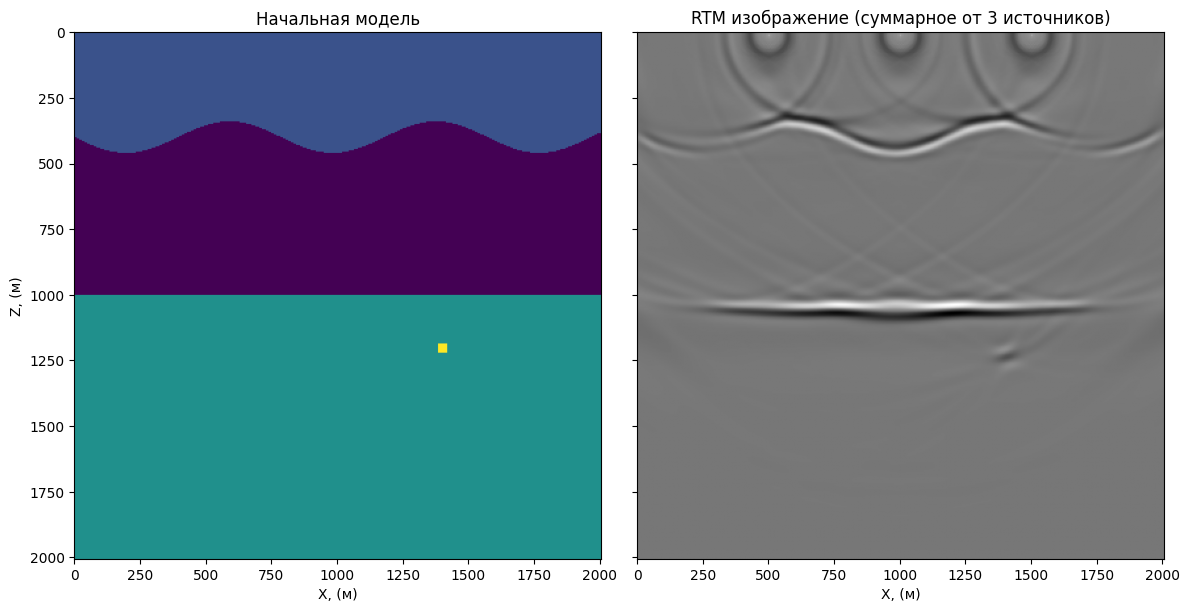

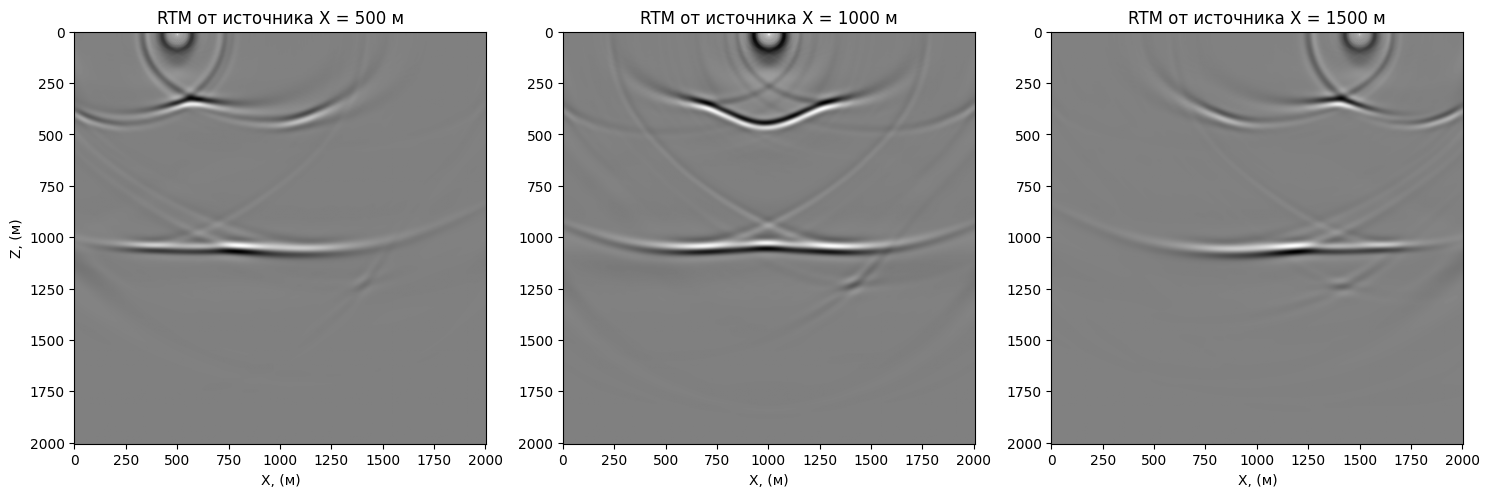

In [14]:
# Применяем условие изображения для каждого источника и суммируем
rtm_images = []

print("Применение условия изображения для каждого источника...")
for source_idx, (forward_snapshots, forward_times, forward_indices,
                 backward_snapshots, backward_times, backward_indices, source_x) in enumerate(
    zip(forward_snapshots_all, forward_times_all, forward_indices_all,
        backward_snapshots_all, backward_times_all, backward_indices_all, sx)):
    
    print(f"\nИсточник {source_idx + 1}/3 (X = {source_x} м):")
    rtm_image = imaging_condition(
        forward_snapshots, forward_times, forward_indices,
        backward_snapshots, backward_times, backward_indices,
        nt_fd, dt_fd, n_pad
    )
    rtm_images.append(rtm_image)

# Суммируем изображения от всех источников
rtm_image_stacked = np.sum(rtm_images, axis=0)
print(f"\n=== Итоговое суммарное RTM изображение ===")
print(f"Размер: {rtm_image_stacked.shape}")
print(f"Максимальная амплитуда: {np.abs(rtm_image_stacked).max():.2e}")
print(f"Средняя амплитуда: {np.abs(rtm_image_stacked).mean():.2e}")

# Визуализация: модель и суммарное RTM изображение
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

axes[0].imshow(v_model, cmap='viridis', extent=[0, nx*dx, nz*dz, 0])
axes[0].set_title('Начальная модель')
axes[0].set_xlabel('X, (м)')
axes[0].set_ylabel('Z, (м)')

axes[1].imshow(rtm_image_stacked, cmap='gray', extent=[0, nx*dx, nz*dz, 0])
axes[1].set_title('RTM изображение (суммарное от 3 источников)')
axes[1].set_xlabel('X, (м)')

plt.tight_layout()
plt.show()

# Дополнительно: показываем отдельные изображения от каждого источника
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, (rtm_image, source_x) in enumerate(zip(rtm_images, sx)):
    im = axes[i].imshow(rtm_image, cmap='gray', extent=[0, nx*dx, nz*dz, 0])
    axes[i].set_title(f'RTM от источника X = {source_x} м')
    axes[i].set_xlabel('X, (м)')
    if i == 0:
        axes[i].set_ylabel('Z, (м)')   
plt.tight_layout()
plt.show()

## 8. Анализ результатов

* На изображении видны некоторые артефакты, особенно сильные вблизи источников. Борьба с ними - отдельная тема, которую в данном примере мы рассматривать не будем. 

* Видно, как изображение для каждого источника уверенно прорисовывается только в некоторой области, за пределами которой картинка расплывается. Потому и важно "освещение" объекта с максимально возможного числа положений источника 